# Customer Churn Prediction

## Project Overview

This project uses Machine Learning to predict whether a telecommunications customer is likely to churn.

The project includes data cleaning, exploratory data analysis, preprocessing, model training, evaluation, feature analysis, and a simple interactive prediction interface.

### Main Goal

The main goal is to identify customers who are at high risk of leaving the company so that the business can take proactive retention actions.

### Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Gradio
- Google Colab

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (7043, 21)


In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
print(df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


# Exploratory Data Analysis (EDA).

In [ ]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [ ]:
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.463013
Yes,26.536987


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# \# Business Insight:

# 1️⃣ Contract

In [ ]:
pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


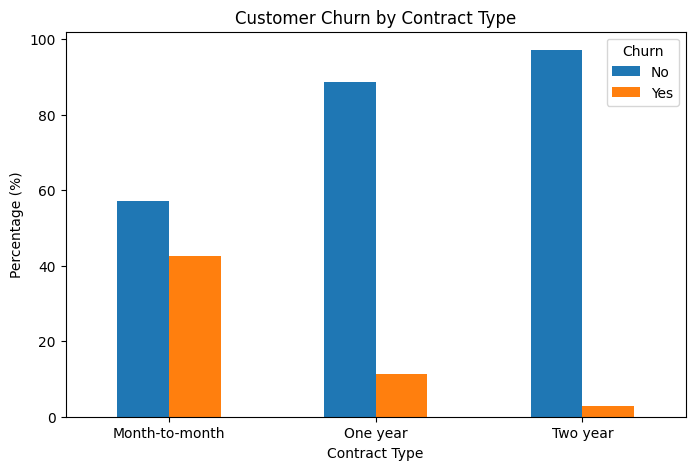

In [ ]:
churn_by_contract = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

churn_by_contract.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

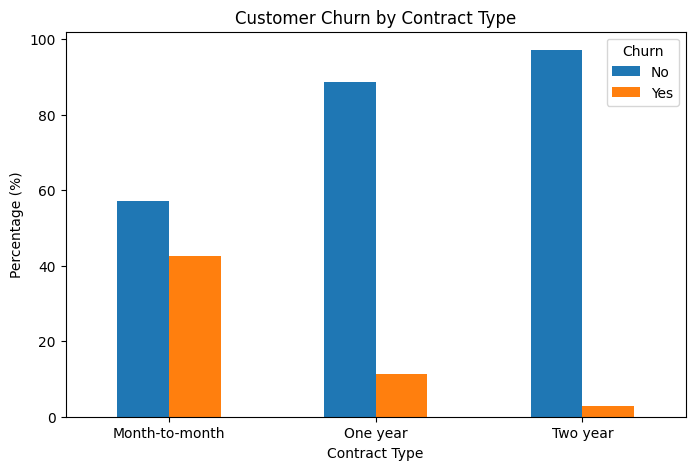

In [ ]:
churn_by_contract = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

churn_by_contract.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

# 2️⃣ Tenure

In [ ]:
df.groupby("Churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


# Customers with shorter tenure appear to have a substantially higher churn rate than long-term customers.

# 3️⃣ Monthly Charges

In [ ]:
df.groupby("Churn")["MonthlyCharges"].mean()

,MonthlyCharges
Churn,
No,61.265124
Yes,74.441332


# Data ***Cleaning***

In [ ]:
df_original = df.copy()

print("Original dataset backup created.")

Original dataset backup created.


In [ ]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [ ]:
print("Missing values in TotalCharges:")
print(df["TotalCharges"].isna().sum())

Missing values in TotalCharges:
11


In [ ]:
df[df["TotalCharges"].isna()][
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


In [ ]:
df_original = df.copy()

In [ ]:
df = df.dropna(subset=["TotalCharges"])

print("Dataset shape after cleaning:", df.shape)

Dataset shape after cleaning: (7032, 21)


In [ ]:
missing_values = df.isnull().sum()

print(missing_values[missing_values > 0])

Series([], dtype: int64)


# Encoding


In [ ]:
for column in df.select_dtypes(include="object").columns:
    print(f"\n{column}:")
    print(df[column].unique())


customerID:
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

gender:
['Female' 'Male']

Partner:
['Yes' 'No']

Dependents:
['No' 'Yes']

PhoneService:
['No' 'Yes']

MultipleLines:
['No phone service' 'No' 'Yes']

InternetService:
['DSL' 'Fiber optic' 'No']

OnlineSecurity:
['No' 'Yes' 'No internet service']

OnlineBackup:
['Yes' 'No' 'No internet service']

DeviceProtection:
['No' 'Yes' 'No internet service']

TechSupport:
['No' 'Yes' 'No internet service']

StreamingTV:
['No' 'Yes' 'No internet service']

StreamingMovies:
['No' 'Yes' 'No internet service']

Contract:
['Month-to-month' 'One year' 'Two year']

PaperlessBilling:
['Yes' 'No']

PaymentMethod:
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

Churn:
['No' 'Yes']


# Encoding:


In [ ]:
X = df.drop(columns=["Churn", "customerID"])
y = df["Churn"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7032, 19)
Target shape: (7032,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (5625, 19)
Testing set: (1407, 19)


In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = X_train.select_dtypes(include=["object"]).columns
numeric_features = X_train.select_dtypes(exclude=["object"]).columns

print("Categorical features:")
print(categorical_features.tolist())

print("\nNumeric features:")
print(numeric_features.tolist())

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numeric features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


# Preprocessor:


In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

print("Preprocessor created successfully!")

Preprocessor created successfully!


In [ ]:
handle_unknown="ignore"

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

print("Model pipeline created successfully!")

Model pipeline created successfully!


In [ ]:
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
y_pred = model.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2%}")

Accuracy: 80.31%


In [ ]:
print("Runtime is working!")

Runtime is working!


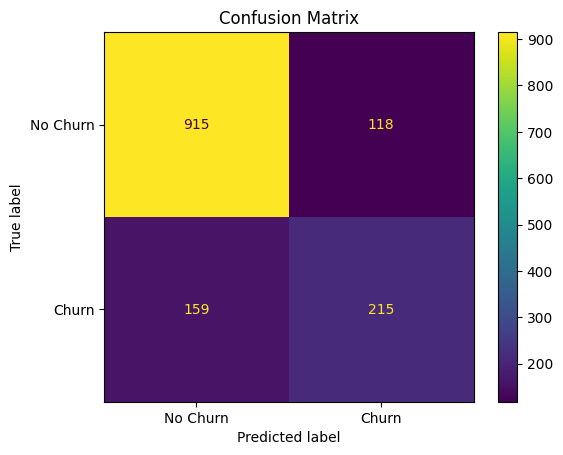

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[915 118]
 [159 215]]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       0.85      0.89      0.87      1033
         Yes       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

print("Random Forest model created successfully!")

Random Forest model created successfully!


In [ ]:
rf_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [ ]:
rf_pred = rf_model.predict(X_test)

print("Random Forest predictions generated successfully!")

Random Forest predictions generated successfully!


In [ ]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, rf_pred)

print(f"Random Forest Accuracy: {rf_accuracy:.2%}")

Random Forest Accuracy: 78.39%


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

          No       0.82      0.90      0.86      1033
         Yes       0.62      0.47      0.54       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.70      1407
weighted avg       0.77      0.78      0.77      1407



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

balanced_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        ))
    ]
)

print("Balanced Logistic Regression created successfully!")

Balanced Logistic Regression created successfully!


In [ ]:
balanced_model.fit(X_train, y_train)

print("Balanced model trained successfully!")

Balanced model trained successfully!


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Balanced Logistic Regression

In [ ]:
balanced_pred = balanced_model.predict(X_test)

print("Balanced model predictions generated successfully!")

Balanced model predictions generated successfully!


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, balanced_pred))

              precision    recall  f1-score   support

          No       0.91      0.70      0.79      1033
         Yes       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.74      1407



In [ ]:
balanced_proba = balanced_model.predict_proba(X_test)[:, 1]

print(balanced_proba[:10])

[0.05029473 0.78005838 0.01338264 0.40707933 0.23132504 0.73121009
 0.07106108 0.35357055 0.83680138 0.04574753]


In [ ]:
from sklearn.metrics import classification_report

threshold = 0.4

balanced_pred_04 = (balanced_proba >= threshold).astype(int)

print(classification_report(
    y_test.map({"No": 0, "Yes": 1}),
    balanced_pred_04,
    target_names=["No", "Yes"]
))

              precision    recall  f1-score   support

          No       0.93      0.62      0.74      1033
         Yes       0.45      0.87      0.59       374

    accuracy                           0.68      1407
   macro avg       0.69      0.74      0.67      1407
weighted avg       0.80      0.68      0.70      1407



In [ ]:
feature_names = balanced_model.named_steps["preprocessor"].get_feature_names_out()

coefficients = balanced_model.named_steps["classifier"].coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

feature_importance["AbsoluteCoefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "AbsoluteCoefficient",
    ascending=False
)

feature_importance.head(15)

,Feature,Coefficient,AbsoluteCoefficient
34,cat__Contract_Two year,-0.753910,0.753910
32,cat__Contract_Month-to-month,0.753477,0.753477
12,cat__InternetService_Fiber optic,0.316104,0.316104
11,cat__InternetService_DSL,-0.290059,0.290059
39,cat__PaymentMethod_Electronic check,0.266056,0.266056
14,cat__OnlineSecurity_No,0.240002,0.240002
23,cat__TechSupport_No,0.218970,0.218970
8,cat__MultipleLines_No,-0.214055,0.214055
16,cat__OnlineSecurity_Yes,-0.213957,0.213957
41,remainder__SeniorCitizen,0.198348,0.198348


حفظ النموذج

In [ ]:
import joblib

joblib.dump(balanced_model, "customer_churn_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
loaded_model = joblib.load("customer_churn_model.pkl")

print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
test_predictions = loaded_model.predict(X_test)

print("Prediction test successful!")
print(test_predictions[:10])

Prediction test successful!
['No' 'Yes' 'No' 'No' 'No' 'Yes' 'No' 'No' 'Yes' 'No']


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import shutil

project_path = "/content/drive/MyDrive/Customer_Churn_Project"

os.makedirs(project_path, exist_ok=True)

shutil.copy(
    "customer_churn_model.pkl",
    project_path
)

print("Model copied to Google Drive successfully!")
print("Saved in:", project_path)

Model copied to Google Drive successfully!
Saved in: /content/drive/MyDrive/Customer_Churn_Project


In [ ]:
results = {
    "Model": "Balanced Logistic Regression",
    "Accuracy": 0.73,
    "Churn Precision": 0.49,
    "Churn Recall": 0.80,
    "Churn F1-Score": 0.61,
    "Threshold": 0.5
}

results_df = pd.DataFrame([results])

results_df.to_csv(
    "/content/drive/MyDrive/Customer_Churn_Project/model_results.csv",
    index=False
)

print("Model results saved successfully!")

Model results saved successfully!


# Visualization

In [3]:
import pandas as pd

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (7043, 21)


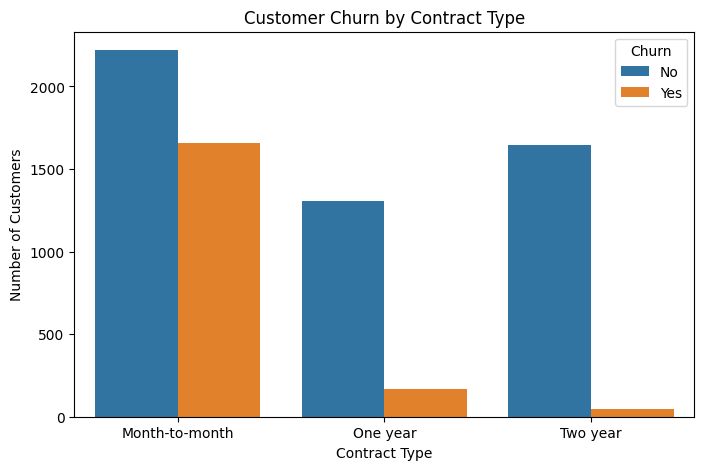

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.show()

In [5]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-12 months", "13-24 months", "25-48 months", "49-72 months"],
    include_lowest=True
)

churn_by_tenure = pd.crosstab(
    df["TenureGroup"],
    df["Churn"],
    normalize="index"
) * 100

print(churn_by_tenure)

Churn                No        Yes
TenureGroup                       
0-12 months   52.561757  47.438243
13-24 months  71.289062  28.710938
25-48 months  79.611041  20.388959
49-72 months  90.486824   9.513176


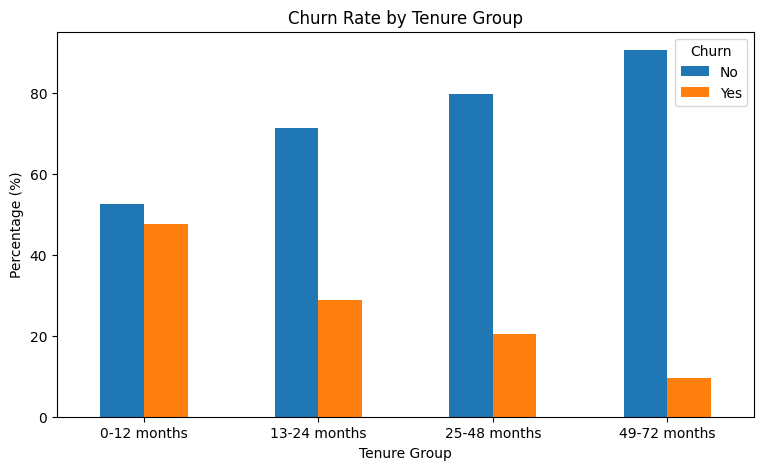

In [6]:
churn_by_tenure.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

In [7]:
print(churn_by_tenure.to_string())

Churn                No        Yes
TenureGroup                       
0-12 months   52.561757  47.438243
13-24 months  71.289062  28.710938
25-48 months  79.611041  20.388959
49-72 months  90.486824   9.513176


## Customers with shorter tenure show significantly higher churn rates. Nearly 47% of customers with 0–12 months of tenure churned, compared with only 9.5% among customers with 49–72 months of tenure. This indicates that early customer retention is an important business priority.

In [8]:
df["MonthlyChargesGroup"] = pd.cut(
    df["MonthlyCharges"],
    bins=[0, 30, 60, 90, 120],
    labels=["0-30", "31-60", "61-90", "91-120"],
    include_lowest=True
)

churn_by_charges = pd.crosstab(
    df["MonthlyChargesGroup"],
    df["Churn"],
    normalize="index"
) * 100

print(churn_by_charges.to_string())

Churn                       No        Yes
MonthlyChargesGroup                      
0-30                 90.199637   9.800363
31-60                74.071146  25.928854
61-90                66.093881  33.906119
91-120               67.222542  32.777458


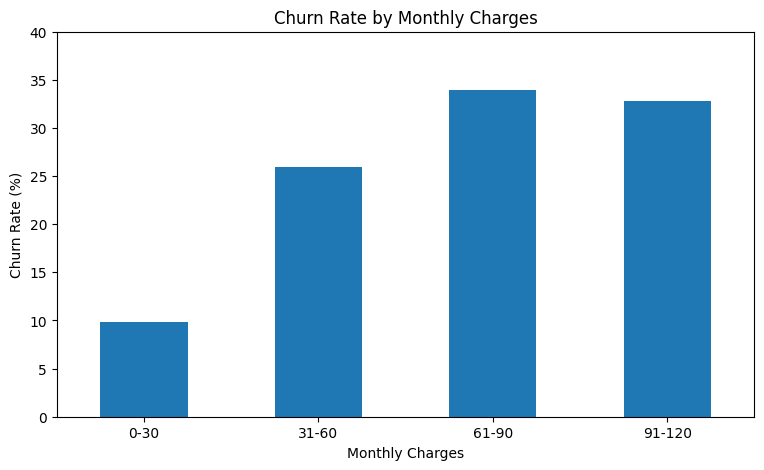

In [9]:
import matplotlib.pyplot as plt

churn_by_charges["Yes"].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn Rate by Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.ylim(0, 40)

plt.show()


Higher monthly charges are associated with higher churn rates, with the highest churn observed among customers paying 61–90 per month.

In [3]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [15]:
import os

print("Drive connected:", os.path.exists("/content/drive/MyDrive"))

project_path = "/content/drive/MyDrive/Customer_Churn_Project"

print("Project folder exists:", os.path.exists(project_path))

if os.path.exists(project_path):
    print("\nFiles inside project folder:")
    print(os.listdir(project_path))

Drive connected: True
Project folder exists: True

Files inside project folder:
['customer_churn_model.pkl', 'model_results.csv']


In [16]:
import joblib

model_path = "/content/drive/MyDrive/Customer_Churn_Project/customer_churn_model.pkl"

balanced_model = joblib.load(model_path)

print("Model loaded successfully!")

Model loaded successfully!


In [17]:
# Example customer
new_customer = pd.DataFrame({
    "gender": ["Female"],
    "SeniorCitizen": [0],
    "Partner": ["Yes"],
    "Dependents": ["No"],
    "tenure": [5],
    "PhoneService": ["Yes"],
    "MultipleLines": ["No"],
    "InternetService": ["Fiber optic"],
    "OnlineSecurity": ["No"],
    "OnlineBackup": ["No"],
    "DeviceProtection": ["No"],
    "TechSupport": ["No"],
    "StreamingTV": ["Yes"],
    "StreamingMovies": ["Yes"],
    "Contract": ["Month-to-month"],
    "PaperlessBilling": ["Yes"],
    "PaymentMethod": ["Electronic check"],
    "MonthlyCharges": [85],
    "TotalCharges": [425]
})

prediction = balanced_model.predict(new_customer)[0]
probability = balanced_model.predict_proba(new_customer)[0][1]

print("Churn Prediction:", prediction)
print(f"Churn Probability: {probability:.2%}")

Churn Prediction: Yes
Churn Probability: 88.73%


In [19]:
def predict_churn(customer_data):
    prediction = balanced_model.predict(customer_data)[0]
    probability = balanced_model.predict_proba(customer_data)[0][1]

    if probability >= 0.70:
        risk = "High"
    elif probability >= 0.40:
        risk = "Medium"
    else:
        risk = "Low"

    return prediction, probability, risk

In [20]:
prediction, probability, risk = predict_churn(new_customer)

print("Churn Prediction:", prediction)
print(f"Churn Probability: {probability:.2%}")
print("Risk Level:", risk)

Churn Prediction: Yes
Churn Probability: 88.73%
Risk Level: High


In [21]:
!pip install -q gradio

In [25]:
def predict_customer_churn(
    gender,
    senior_citizen,
    partner,
    dependents,
    tenure,
    phone_service,
    multiple_lines,
    internet_service,
    online_security,
    online_backup,
    device_protection,
    tech_support,
    streaming_tv,
    streaming_movies,
    contract,
    paperless_billing,
    payment_method,
    monthly_charges,
    total_charges
):

    customer = pd.DataFrame({
        "gender": [gender],
        "SeniorCitizen": [senior_citizen],
        "Partner": [partner],
        "Dependents": [dependents],
        "tenure": [tenure],
        "PhoneService": [phone_service],
        "MultipleLines": [multiple_lines],
        "InternetService": [internet_service],
        "OnlineSecurity": [online_security],
        "OnlineBackup": [online_backup],
        "DeviceProtection": [device_protection],
        "TechSupport": [tech_support],
        "StreamingTV": [streaming_tv],
        "StreamingMovies": [streaming_movies],
        "Contract": [contract],
        "PaperlessBilling": [paperless_billing],
        "PaymentMethod": [payment_method],
        "MonthlyCharges": [monthly_charges],
        "TotalCharges": [total_charges]
    })

    prediction = balanced_model.predict(customer)[0]
    probability = balanced_model.predict_proba(customer)[0][1]

    if probability >= 0.70:
        risk = "HIGH"
    elif probability >= 0.40:
        risk = "MEDIUM"
    else:
        risk = "LOW"

    return str(prediction), f"{probability:.2%}", risk

In [26]:
import gradio as gr

def test_prediction():
    prediction = balanced_model.predict(new_customer)[0]
    probability = balanced_model.predict_proba(new_customer)[0][1]

    if probability >= 0.70:
        risk = "HIGH"
    elif probability >= 0.40:
        risk = "MEDIUM"
    else:
        risk = "LOW"

    return str(prediction), f"{probability:.2%}", risk


demo = gr.Interface(
    fn=test_prediction,
    inputs=[],
    outputs=[
        gr.Textbox(label="Churn Prediction"),
        gr.Textbox(label="Churn Probability"),
        gr.Textbox(label="Risk Level")
    ],
    title="Customer Churn Prediction"
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b3825642d24e794266.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [27]:
prediction = balanced_model.predict(new_customer)[0]
probability = balanced_model.predict_proba(new_customer)[0][1]

print("Prediction:", prediction)
print("Probability:", f"{probability:.2%}")

Prediction: Yes
Probability: 88.73%


In [28]:
print("Model is working correctly!")

Model is working correctly!


In [29]:
import gradio as gr
import pandas as pd

def predict_customer(
    gender,
    senior_citizen,
    partner,
    dependents,
    tenure,
    phone_service,
    multiple_lines,
    internet_service,
    online_security,
    online_backup,
    device_protection,
    tech_support,
    streaming_tv,
    streaming_movies,
    contract,
    paperless_billing,
    payment_method,
    monthly_charges,
    total_charges
):

    customer = pd.DataFrame({
        "gender": [gender],
        "SeniorCitizen": [senior_citizen],
        "Partner": [partner],
        "Dependents": [dependents],
        "tenure": [tenure],
        "PhoneService": [phone_service],
        "MultipleLines": [multiple_lines],
        "InternetService": [internet_service],
        "OnlineSecurity": [online_security],
        "OnlineBackup": [online_backup],
        "DeviceProtection": [device_protection],
        "TechSupport": [tech_support],
        "StreamingTV": [streaming_tv],
        "StreamingMovies": [streaming_movies],
        "Contract": [contract],
        "PaperlessBilling": [paperless_billing],
        "PaymentMethod": [payment_method],
        "MonthlyCharges": [monthly_charges],
        "TotalCharges": [total_charges]
    })

    prediction = balanced_model.predict(customer)[0]
    probability = balanced_model.predict_proba(customer)[0][1]

    if probability >= 0.70:
        risk = "HIGH"
    elif probability >= 0.40:
        risk = "MEDIUM"
    else:
        risk = "LOW"

    return (
        str(prediction),
        f"{probability:.2%}",
        risk
    )


demo = gr.Interface(
    fn=predict_customer,

    inputs=[
        gr.Dropdown(["Female", "Male"], label="Gender"),
        gr.Dropdown([0, 1], label="Senior Citizen"),
        gr.Dropdown(["Yes", "No"], label="Partner"),
        gr.Dropdown(["Yes", "No"], label="Dependents"),
        gr.Number(label="Tenure (months)", value=12),

        gr.Dropdown(["Yes", "No"], label="Phone Service"),
        gr.Dropdown(
            ["Yes", "No", "No phone service"],
            label="Multiple Lines"
        ),

        gr.Dropdown(
            ["DSL", "Fiber optic", "No"],
            label="Internet Service"
        ),

        gr.Dropdown(
            ["Yes", "No", "No internet service"],
            label="Online Security"
        ),

        gr.Dropdown(
            ["Yes", "No", "No internet service"],
            label="Online Backup"
        ),

        gr.Dropdown(
            ["Yes", "No", "No internet service"],
            label="Device Protection"
        ),

        gr.Dropdown(
            ["Yes", "No", "No internet service"],
            label="Tech Support"
        ),

        gr.Dropdown(
            ["Yes", "No", "No internet service"],
            label="Streaming TV"
        ),

        gr.Dropdown(
            ["Yes", "No", "No internet service"],
            label="Streaming Movies"
        ),

        gr.Dropdown(
            ["Month-to-month", "One year", "Two year"],
            label="Contract"
        ),

        gr.Dropdown(
            ["Yes", "No"],
            label="Paperless Billing"
        ),

        gr.Dropdown(
            [
                "Electronic check",
                "Mailed check",
                "Bank transfer (automatic)",
                "Credit card (automatic)"
            ],
            label="Payment Method"
        ),

        gr.Number(label="Monthly Charges", value=50),
        gr.Number(label="Total Charges", value=500)
    ],

    outputs=[
        gr.Textbox(label="Churn Prediction"),
        gr.Textbox(label="Churn Probability"),
        gr.Textbox(label="Risk Level")
    ],

    title="📊 Customer Churn Prediction",
    description="Enter customer information to predict the likelihood of churn."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9828d89f6a2f59b278.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


مع نظام توصية

In [30]:
import gradio as gr
import pandas as pd

def predict_customer(
    gender,
    senior_citizen,
    partner,
    dependents,
    tenure,
    phone_service,
    multiple_lines,
    internet_service,
    online_security,
    online_backup,
    device_protection,
    tech_support,
    streaming_tv,
    streaming_movies,
    contract,
    paperless_billing,
    payment_method,
    monthly_charges,
    total_charges
):

    customer = pd.DataFrame({
        "gender": [gender],
        "SeniorCitizen": [senior_citizen],
        "Partner": [partner],
        "Dependents": [dependents],
        "tenure": [tenure],
        "PhoneService": [phone_service],
        "MultipleLines": [multiple_lines],
        "InternetService": [internet_service],
        "OnlineSecurity": [online_security],
        "OnlineBackup": [online_backup],
        "DeviceProtection": [device_protection],
        "TechSupport": [tech_support],
        "StreamingTV": [streaming_tv],
        "StreamingMovies": [streaming_movies],
        "Contract": [contract],
        "PaperlessBilling": [paperless_billing],
        "PaymentMethod": [payment_method],
        "MonthlyCharges": [monthly_charges],
        "TotalCharges": [total_charges]
    })

    prediction = balanced_model.predict(customer)[0]
    probability = balanced_model.predict_proba(customer)[0][1]

    if probability >= 0.70:
        risk = "HIGH"
        recommendation = (
            "High churn risk. "
            "Consider contacting the customer and offering a suitable "
            "retention plan or discount."
        )

    elif probability >= 0.40:
        risk = "MEDIUM"
        recommendation = (
            "Medium churn risk. "
            "Consider monitoring the customer and reviewing their "
            "services and satisfaction."
        )

    else:
        risk = "LOW"
        recommendation = (
            "Low churn risk. "
            "Continue regular customer engagement and monitoring."
        )

    return (
        str(prediction),
        f"{probability:.2%}",
        risk,
        recommendation
    )


demo = gr.Interface(
    fn=predict_customer,

    inputs=[
        gr.Dropdown(["Female", "Male"], label="Gender"),
        gr.Dropdown([0, 1], label="Senior Citizen"),
        gr.Dropdown(["Yes", "No"], label="Partner"),
        gr.Dropdown(["Yes", "No"], label="Dependents"),
        gr.Number(label="Tenure (months)", value=12),

        gr.Dropdown(["Yes", "No"], label="Phone Service"),
        gr.Dropdown(
            ["Yes", "No", "No phone service"],
            label="Multiple Lines"
        ),

        gr.Dropdown(
            ["DSL", "Fiber optic", "No"],
            label="Internet Service"
        ),

        gr.Dropdown(
            ["Yes", "No", "No internet service"],
            label="Online Security"
        ),

        gr.Dropdown(
            ["Yes", "No", "No internet service"],
            label="Online Backup"
        ),

        gr.Dropdown(
            ["Yes", "No", "No internet service"],
            label="Device Protection"
        ),

        gr.Dropdown(
            ["Yes", "No", "No internet service"],
            label="Tech Support"
        ),

        gr.Dropdown(
            ["Yes", "No", "No internet service"],
            label="Streaming TV"
        ),

        gr.Dropdown(
            ["Yes", "No", "No internet service"],
            label="Streaming Movies"
        ),

        gr.Dropdown(
            ["Month-to-month", "One year", "Two year"],
            label="Contract"
        ),

        gr.Dropdown(
            ["Yes", "No"],
            label="Paperless Billing"
        ),

        gr.Dropdown(
            [
                "Electronic check",
                "Mailed check",
                "Bank transfer (automatic)",
                "Credit card (automatic)"
            ],
            label="Payment Method"
        ),

        gr.Number(label="Monthly Charges", value=50),
        gr.Number(label="Total Charges", value=500)
    ],

    outputs=[
        gr.Textbox(label="Churn Prediction"),
        gr.Textbox(label="Churn Probability"),
        gr.Textbox(label="Risk Level"),
        gr.Textbox(label="Business Recommendation")
    ],

    title="📊 Customer Churn Prediction",
    description=(
        "Predict customer churn risk and receive a business recommendation."
    )
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://29e1046643cb4b5cfc.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [4]:
import os

project_path = "/content/drive/MyDrive/Customer_Churn_Project"

print("Files in project folder:")
for file in os.listdir(project_path):
    print(file)

Files in project folder:
customer_churn_model.pkl
model_results.csv
